Coefficients calculés :
  a (pertes quadratiques) : 6.31313131e-08 (Coordonnée physique cohérente : True)
  b (consommation active) : 8.83838384e-06 (Coordonnée physique cohérente : True)
  c (pertes de veille)    : 1.01010101e-04 (Coordonnée physique cohérente : True)
Rendement résultant au point de longévité (80.0 kW) : 55000.00%


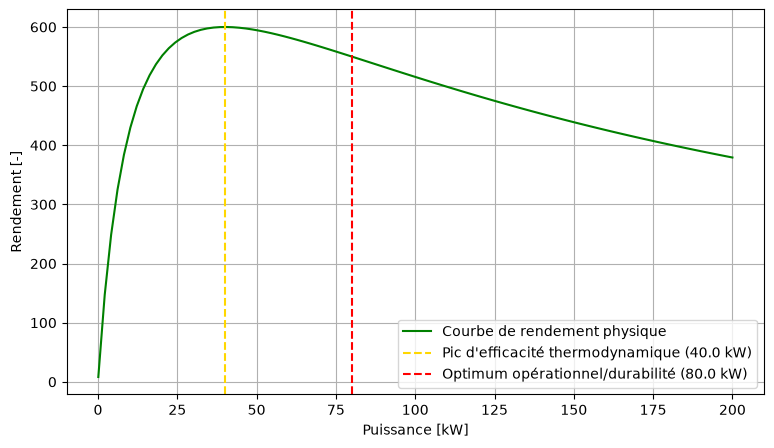

In [2]:
import numpy as np
import matplotlib.pyplot as plt

p_max = 200.0   # kW
p_nom = 80.0    # kW (point de fonctionnement optimal pour la durée de vie)
LHV = 120.0     # kJ/g

# --- Tes choix physiques ---
p_peak = 40.0   # On force le pic d'efficacité à 40 kW (20% de P_max)
eta_peak = 0.60 # Rendement au pic (60%)
eta_max = 0.40  # Rendement à puissance max (40%)

# --- Calcul des paramètres ---
alpha = p_max / (p_max - p_peak)**2 * (1.0 / eta_max - 1.0 / eta_peak)
beta = 1.0 / eta_peak - 2.0 * alpha * p_peak
gamma = alpha * p_peak ** 2

a, b, c = alpha / LHV, beta / LHV, gamma / LHV
a=6.31313131e-08 
b=8.83838384e-06
c=1.01010101e-04 

# --- Vérifications qualitatives ---
print("Coefficients calculés :")
print(f"  a (pertes quadratiques) : {a:.8e} (Coordonnée physique cohérente : {a > 0})")
print(f"  b (consommation active) : {b:.8e} (Coordonnée physique cohérente : {b > 0})")
print(f"  c (pertes de veille)    : {c:.8e} (Coordonnée physique cohérente : {c > 0})")

eta_at_nom = p_nom / ((a * p_nom**2 + b * p_nom + c) * LHV)
print(f"Rendement résultant au point de longévité ({p_nom} kW) : {eta_at_nom:.2%}")

# --- Tracé de la courbe de rendement ---
p_vec = np.linspace(0.1, p_max, 100)
plt.figure(figsize=(9, 5))
plt.plot(p_vec, p_vec / (a * p_vec**2 + b * p_vec + c) / LHV, label="Courbe de rendement physique", color="green")
plt.axvline(p_peak, color="gold", linestyle="--", label=f"Pic d'efficacité thermodynamique ({p_peak} kW)")
plt.axvline(p_nom, color="red", linestyle="--", label=f"Optimum opérationnel/durabilité ({p_nom} kW)")
plt.xlabel("Puissance [kW]")
plt.ylabel("Rendement [-]")
plt.legend()
plt.grid(True)
plt.show()

In [7]:
import numpy as np
import matplotlib.pyplot as plt

p_max = 800.0   # kW
p_nom = 0.4 * p_max   # kW (optimal operating point for component lifetime)
LHV = 120000.0     # kJ/kg

# --- Physical choices ---
p_peak = 0.2 * p_max   # Forcing the efficiency peak at 40 kW (20% of P_max)
eta_peak = 0.60 # Peak efficiency (60%)
eta_nom = 0.55  # Target efficiency at nominal power (55%)

# --- Parameter calculations ---
# The math now derives alpha using the nominal point instead of the maximum power point
alpha = p_nom / (p_nom - p_peak)**2 * (1.0 / eta_nom - 1.0 / eta_peak)
beta = 1.0 / eta_peak - 2.0 * alpha * p_peak
gamma = alpha * p_peak ** 2

a, b, c = alpha / LHV, beta / LHV, gamma / LHV

# --- Qualitative verifications ---
print("Calculated coefficients:")
print(f"  a (quadratic losses)  : {a:.8e} (Physically coherent: {a > 0})")
print(f"  b (active consumption): {b:.8e} (Physically coherent: {b > 0})")
print(f"  c (standby/idle losses): {c:.8e} (Physically coherent: {c > 0})")

eta_at_nom = p_nom / ((a * p_nom**2 + b * p_nom + c) * LHV)
print(f"Resulting efficiency at the nominal point ({p_nom} kW): {eta_at_nom:.2%}")

eta_at_max = p_max / ((a * p_max**2 + b * p_max + c) * LHV)
print(f"Resulting efficiency at maximum power ({p_max} kW): {eta_at_max:.2%}")

# --- Plotting the efficiency curve ---
p_vec = np.linspace(0.1, p_max, 100)
plt.figure(figsize=(9, 5))
plt.plot(p_vec, p_vec / (a * p_vec**2 + b * p_vec + c) / LHV, label="Physical efficiency curve", color="green")
plt.axvline(p_peak, color="gold", linestyle="--", label=f"Thermodynamic efficiency peak ({p_peak} kW)")
plt.axvline(p_nom, color="red", linestyle="--", label=f"Operational/durability optimum ({p_nom} kW)")
plt.xlabel("Power [kW]")
plt.ylabel("Efficiency [-]")
plt.legend()
plt.grid(True)
plt.show()

print(f"a0: float ={c:.8e}    # [g/s]")
print(f"a1: float ={b:.8e}    # [g/(s*kW)]")
print(f"a2: float ={a:.8e}    # [g/(s*kW^2)]")

Calculated coefficients:
  a (quadratic losses)  : 1.57828283e-08 (Physically coherent: True)
  b (active consumption): 8.83838384e-06 (Physically coherent: True)
  c (standby/idle losses): 4.04040404e-04 (Physically coherent: True)
Resulting efficiency at the nominal point (320.0 kW): 55.00%
Resulting efficiency at maximum power (800.0 kW): 37.93%


a0: float =4.04040404e-04    # [g/s]
a1: float =8.83838384e-06    # [g/(s*kW)]
a2: float =1.57828283e-08    # [g/(s*kW^2)]
